In [18]:
import pandas as pd

In [19]:
DATASET = '../datasets/libra/synthetic/libra_50K.csv'

df = pd.read_csv(DATASET)
# df = df.iloc[:500000]
df

,id_source,id_destination,cum_amount,nr_transactions,nr_alerts
0,0,12133,732.139323,1,0
1,0,13791,5815.167719,1,0
2,0,15943,39259.154983,1,0
3,0,17007,3900.791947,1,0
4,0,21620,187.407418,1,0
...,...,...,...,...,...
629237,49999,12032,16651.821533,2,0
629238,49999,12382,814.758452,3,0
629239,49999,15859,57831.396991,3,0
629240,49999,19397,22265.861540,2,0


In [22]:
# Dictionary to track the last step of each user
user_steps = {}

# Initialize the step column
df["step"] = 0

# Iterate through transactions
for idx, row in df.iterrows():
    sender = row["id_source"]
    receiver = row["id_destination"]
    
    # Get the last step for sender & receiver (default to -1 if not seen before)
    sender_step = user_steps.get(sender, -1)
    receiver_step = user_steps.get(receiver, -1)
    
    # Assign step: max(sender_step, receiver_step) + 1
    step = max(sender_step, receiver_step) + 1
    df.at[idx, "step"] = step

    # Update user steps
    user_steps[sender] = step
    user_steps[receiver] = step  # Both users are now at this step

# Check output
print(df.head(10))


   id_source  id_destination    cum_amount  nr_transactions  nr_alerts  step
0          0           12133    732.139323                1          0     0
1          0           13791   5815.167719                1          0     1
2          0           15943  39259.154983                1          0     2
3          0           17007   3900.791947                1          0     3
4          0           21620    187.407418                1          0     4
5          0           21695      5.920059                1          0     5
6          0           24852     36.438546                1          0     6
7          0           25624   1027.624612                1          0     7
8          0           27651    123.539075                1          0     8
9          0           37945    260.205903                1          0     9


In [23]:
df

,id_source,id_destination,cum_amount,nr_transactions,nr_alerts,step
0,0,12133,732.139323,1,0,0
1,0,13791,5815.167719,1,0,1
2,0,15943,39259.154983,1,0,2
3,0,17007,3900.791947,1,0,3
4,0,21620,187.407418,1,0,4
...,...,...,...,...,...,...
629237,49999,12032,16651.821533,2,0,1360
629238,49999,12382,814.758452,3,0,1361
629239,49999,15859,57831.396991,3,0,1362
629240,49999,19397,22265.861540,2,0,1363


In [38]:
balances = {}

for _, row in df.iterrows():
    source = int(row["id_source"])
    destination = int(row["id_destination"])
    step = int(row["step"])
    amount = round(float(row["cum_amount"]), 3)  

    # Initialize balances if user appears for the first time
    if source not in balances:
        balances[source] = {step: 0}  # First transaction, balance starts at 0
    if destination not in balances:
        balances[destination] = {step: 0}

    # Get the previous balance (default to 0 if first transaction)
    prev_balance_source = max(balances[source].values(), default=0)
    prev_balance_destination = max(balances[destination].values(), default=0)

    # Update balances for this step
    balances[source][step] = round(prev_balance_source - amount, 3)  # Source loses money
    balances[destination][step] = round(prev_balance_destination + amount, 3)  # Destination gains money

In [39]:
balances

{0: {0: -732.139,
  1: -6547.307,
  2: -39991.294,
  3: -4632.931,
  4: -919.546,
  5: -738.059,
  6: -768.578,
  7: -1759.764,
  8: -855.678,
  9: -992.345,
  10: -7817.342,
  11: -1139.564,
  12: -1166.525,
  13: -1495.184,
  14: -774.933,
  15: -721.723,
  23: 12570.78,
  131: 30994.762,
  567: 31655.889,
  591: 33128.282,
  732: 33773.84,
  1142: 38323.485},
 12133: {0: 732.139,
  145: 857.975,
  146: 1166.776,
  150: -17438.604,
  205: -11814.372,
  397: 1132.491,
  398: 890.438,
  399: 1146.149,
  400: 1112.704,
  401: 958.787,
  402: -7257.021,
  405: -648.171,
  406: 875.55,
  422: 25678.178,
  423: 32605.112,
  473: 33774.287,
  495: 34369.936,
  529: 43221.992,
  531: 43672.403,
  631: 56373.079,
  738: 58882.35,
  827: 62221.211,
  1001: 62380.169,
  1002: 99296.088,
  1136: 100139.91,
  1361: 113050.073},
 13791: {1: 5815.168,
  456: 6021.36,
  457: -11961.366,
  458: 1308.32,
  459: 5328.352,
  460: 5625.987,
  461: 5843.971,
  462: 5367.346,
  463: 3782.338,
  464: -34934

In [40]:
# Create DataFrame
balance_df = pd.DataFrame.from_dict(balances, orient='index').T

# Identify the full range of steps (days)
full_range = range(int(balance_df.index.min()), int(balance_df.index.max()) + 1)

# Reindex to include all steps, then forward fill
balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_7911/2717310840.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')


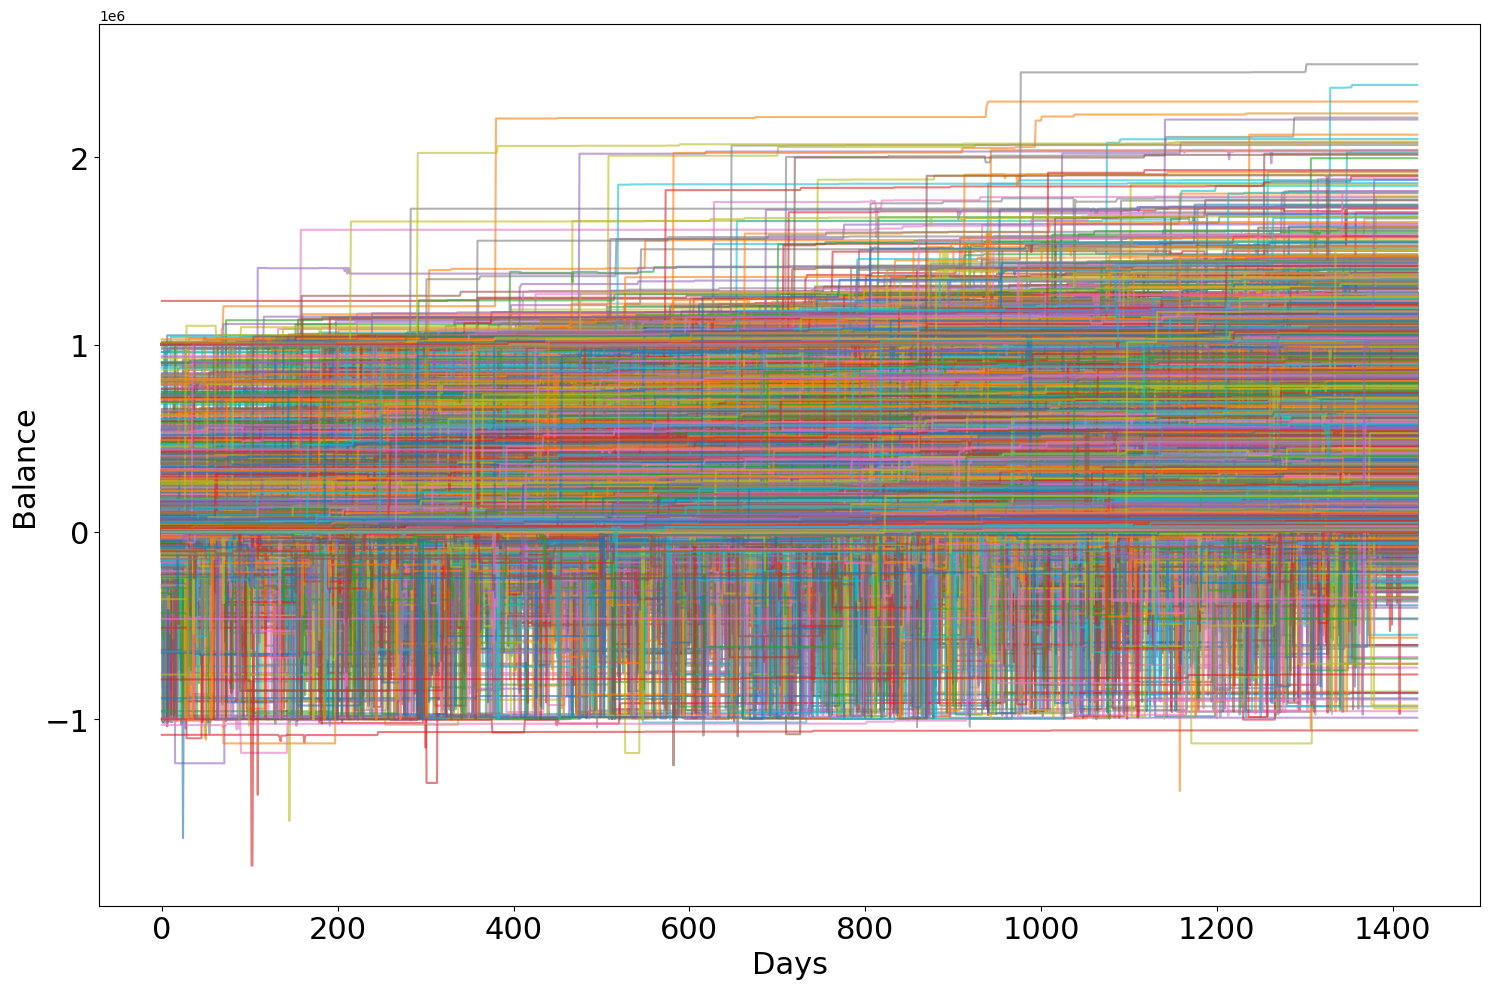

In [41]:
import matplotlib.pyplot as plt

# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in balance_df.columns:
    plt.plot(balance_df.index, balance_df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Display the plot
plt.tight_layout()
plt.show()